In [1]:
%load_ext autoreload
%autoreload 2
import sys
from scipy.optimize import linear_sum_assignment
from matplotlib.lines import Line2D
from cellpose import plot
from csbdeep.utils import normalize

sys.path.append("..")
from src import *

2025-12-03 15:48:33.351786: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-03 15:48:33.382593: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-03 15:48:33.950386: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Cupy Available= 1


## Check that everything is ok

100%|██████████| 11/11 [00:11<00:00,  1.04s/it]


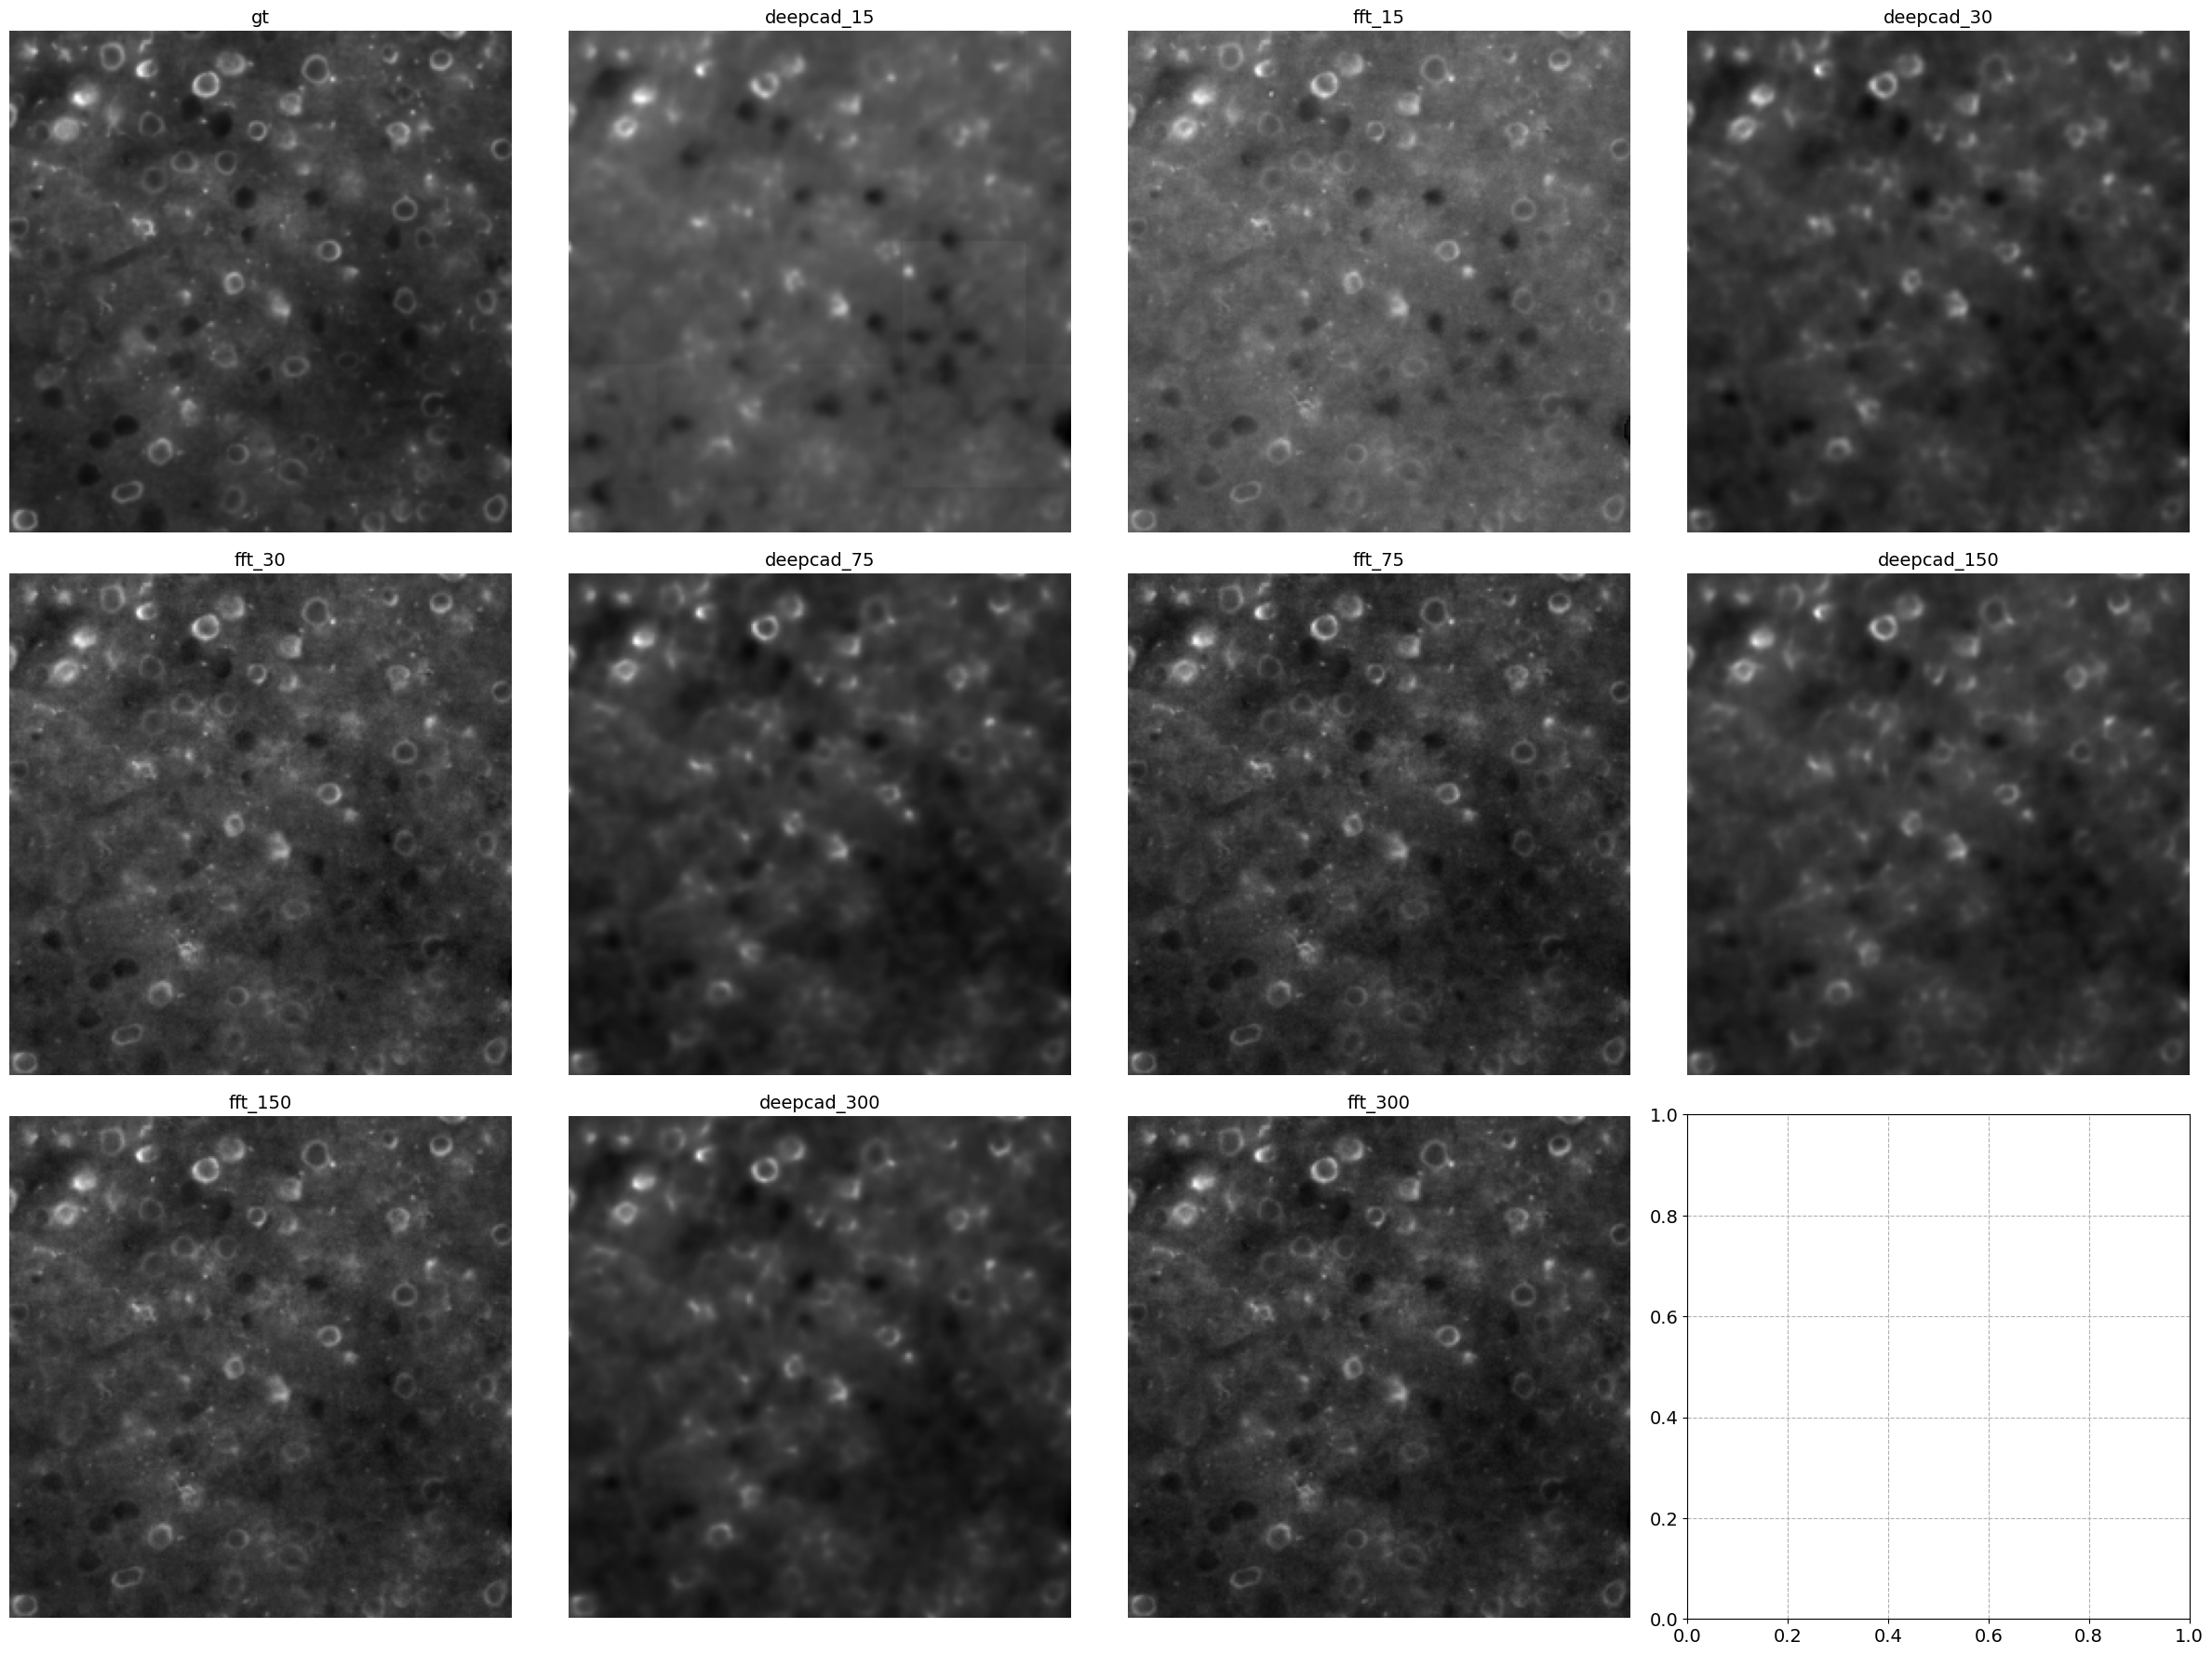

In [2]:
dataset = "synthetic"
folders = [
    "gt",
    "deepcad_15",
    "fft_15",
    "deepcad_30",
    "fft_30",
    "deepcad_75",
    "fft_75",
    "deepcad_150",
    "fft_150",
    "deepcad_300",
    "fft_300",
]
imgs = {}
for folder in tqdm(folders):
    data_path = f"dataset/synthetic/{folder}/data.tiff"
    rec = Recording(data_path, max_frames=10)
    imgs[folder] = rec.np[-1]
imshow(imgs, size=6, zoom=2, cols=4)

## Plotting metrics

In [6]:
def barchart(baseline_df, df, label, col, lims=(0, 1), width=0.75, line_y=None):
    fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=300)

    ax.bar(baseline_df.index, baseline_df[col], label="DeepCAD", color="lightgray", width=width)

    diff = df[col] - baseline_df[col]
    colors = np.where(diff < 0, "salmon", "steelblue")

    ax.bar(
        df.index,
        diff,
        bottom=baseline_df[col],
        label=label,
        color=colors,
        width=width,
    )

    ax.set_ylim(lims)
    ax.set_title(f"{col} comparison")
    ax.set_xlabel("Method")
    ax.set_ylabel(col)
    ax.legend()
    if line_y:
        ax.add_line(Line2D([-1, 5], [line_y] * 2, linestyle="--", color="tab:blue", linewidth=2))
    plt.tight_layout()
    plt.show()

In [ ]:
metrics = pd.read_csv("cellpose_metrics.csv")
metrics

,suffx,ROI GT,ROIs,IoU
0,synthetic_deepcad_15,284.0,101.0,0.267517
1,synthetic_deepcad_150,284.0,192.0,0.462333
2,synthetic_fft_15,284.0,232.0,0.685405
3,synthetic_fft_150,284.0,242.0,0.697820
4,synthetic_deepcad_30,284.0,170.0,0.435010
5,synthetic_fft_30,284.0,240.0,0.729286
6,synthetic_deepcad_75,284.0,188.0,0.453127
7,synthetic_fft_75,284.0,235.0,0.698760
8,synthetic_deepcad_300,284.0,183.0,0.456118
9,synthetic_fft_300,284.0,239.0,0.711500


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


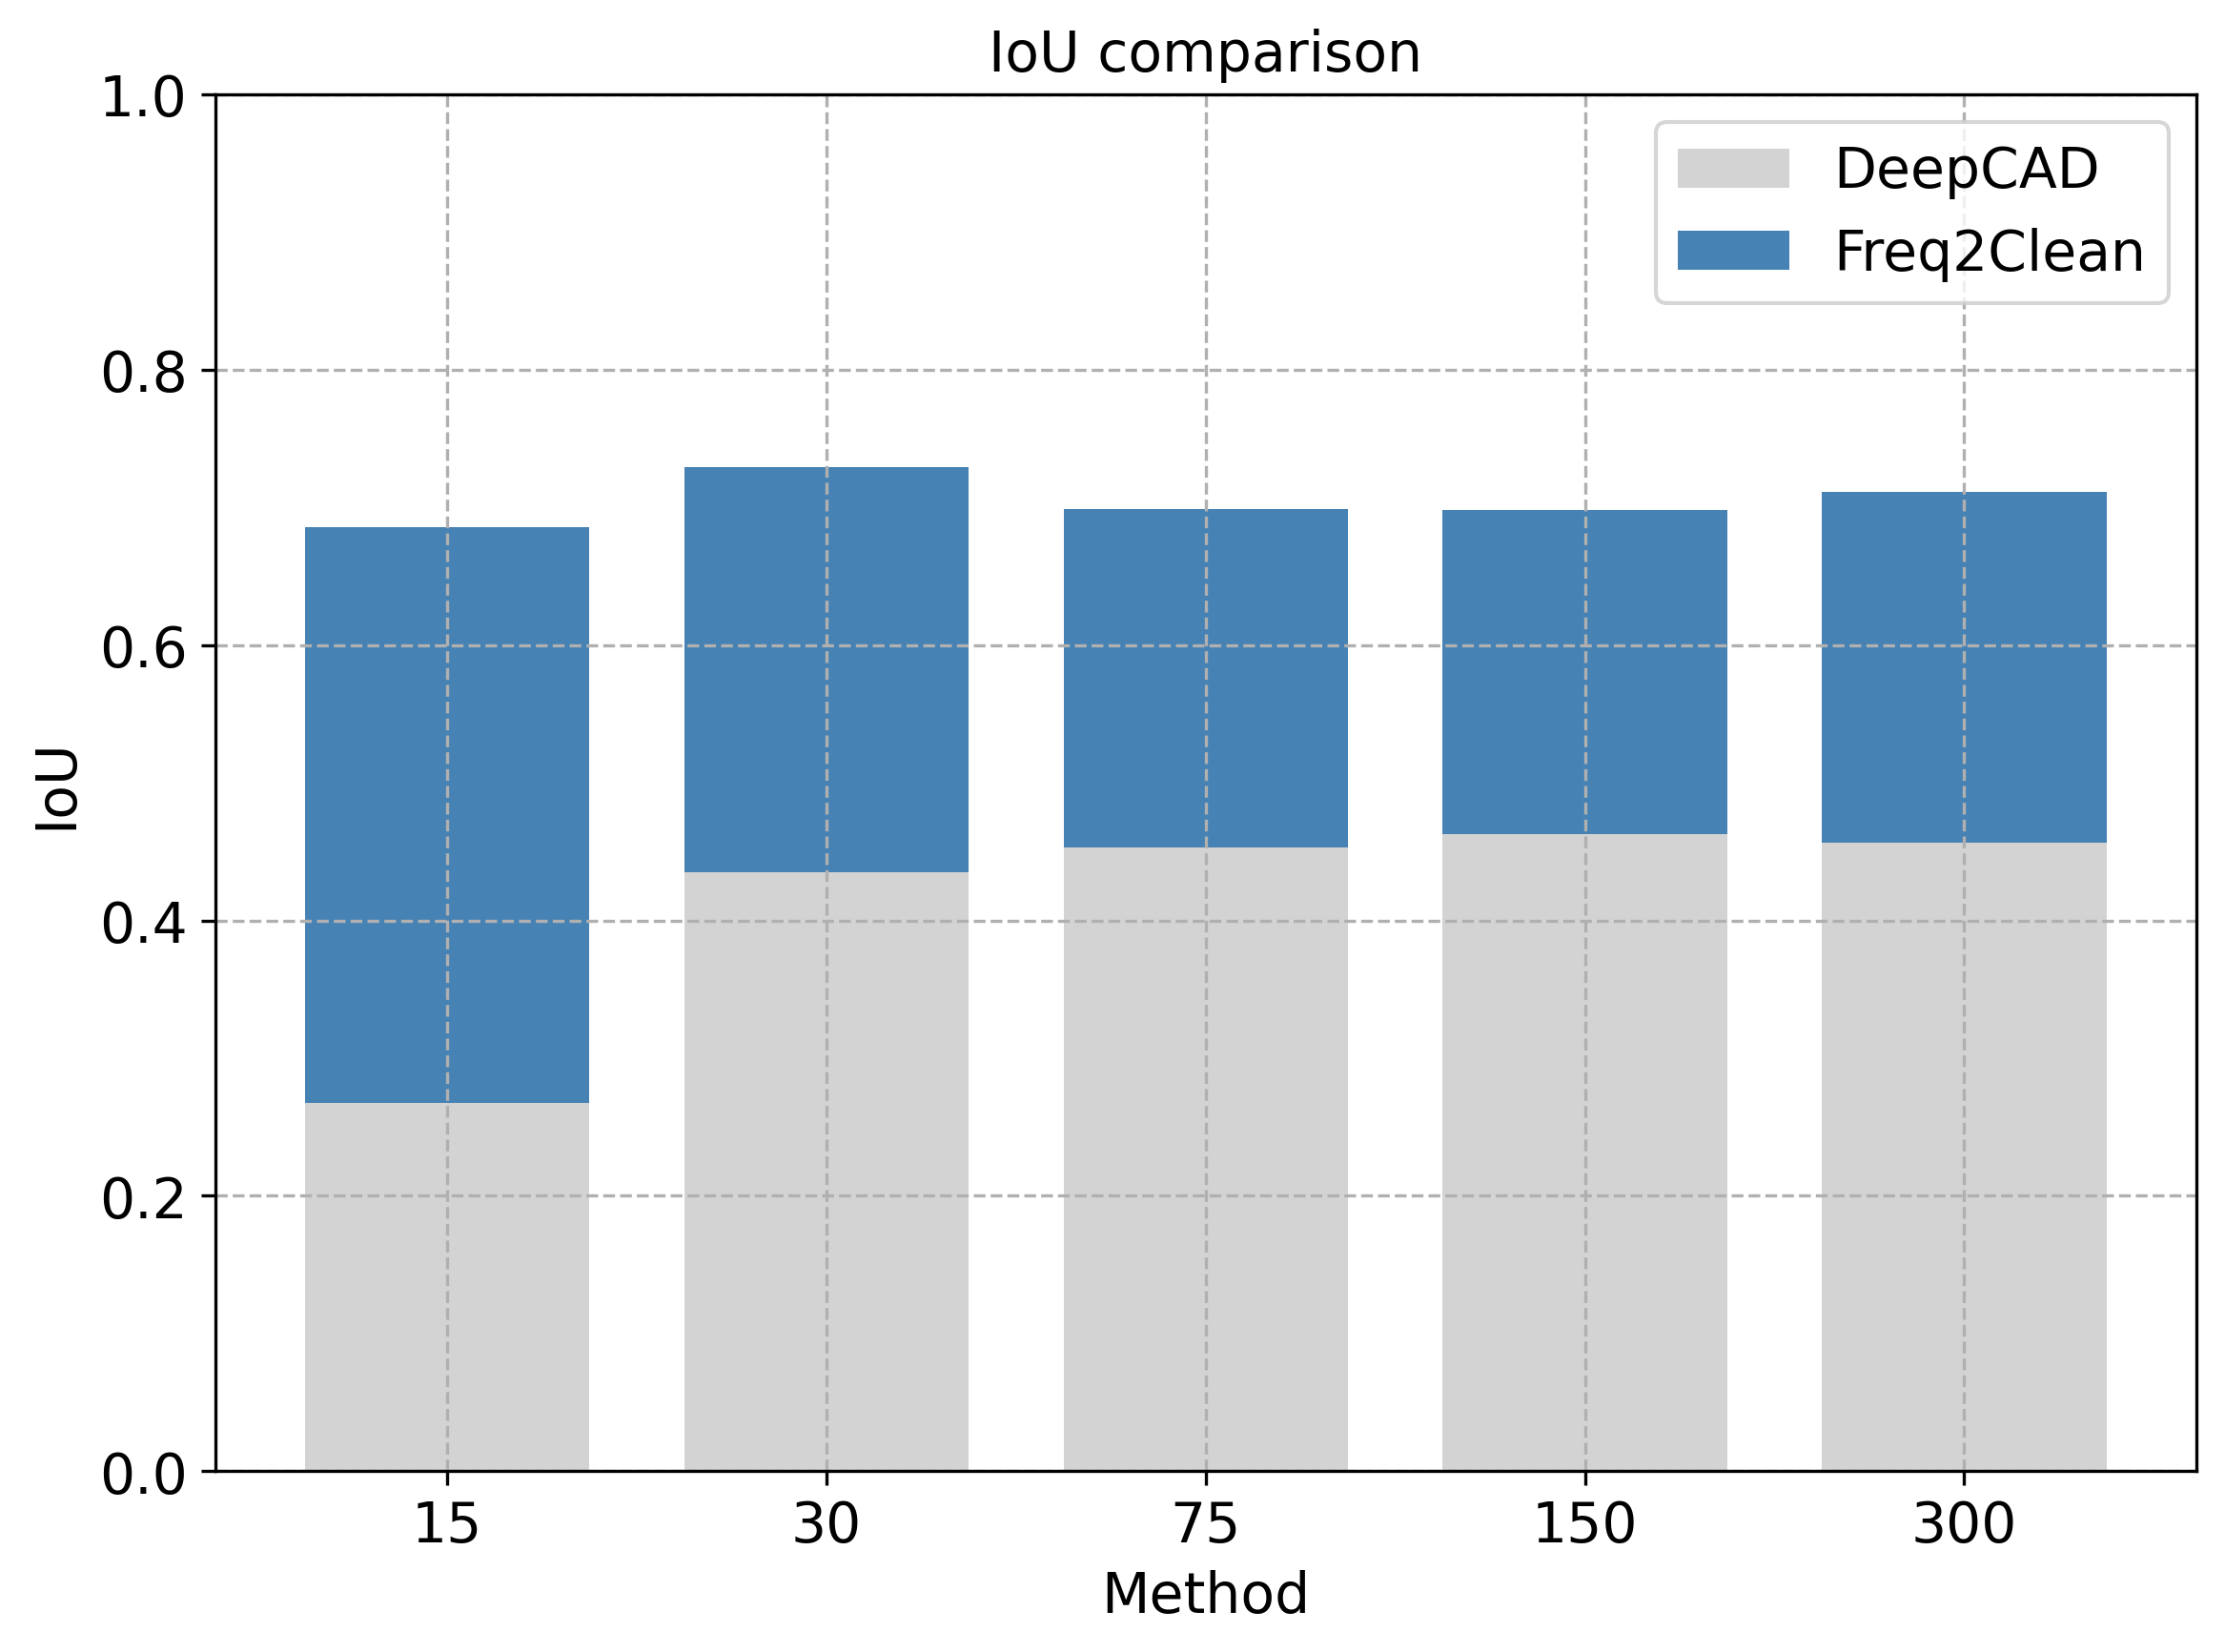

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


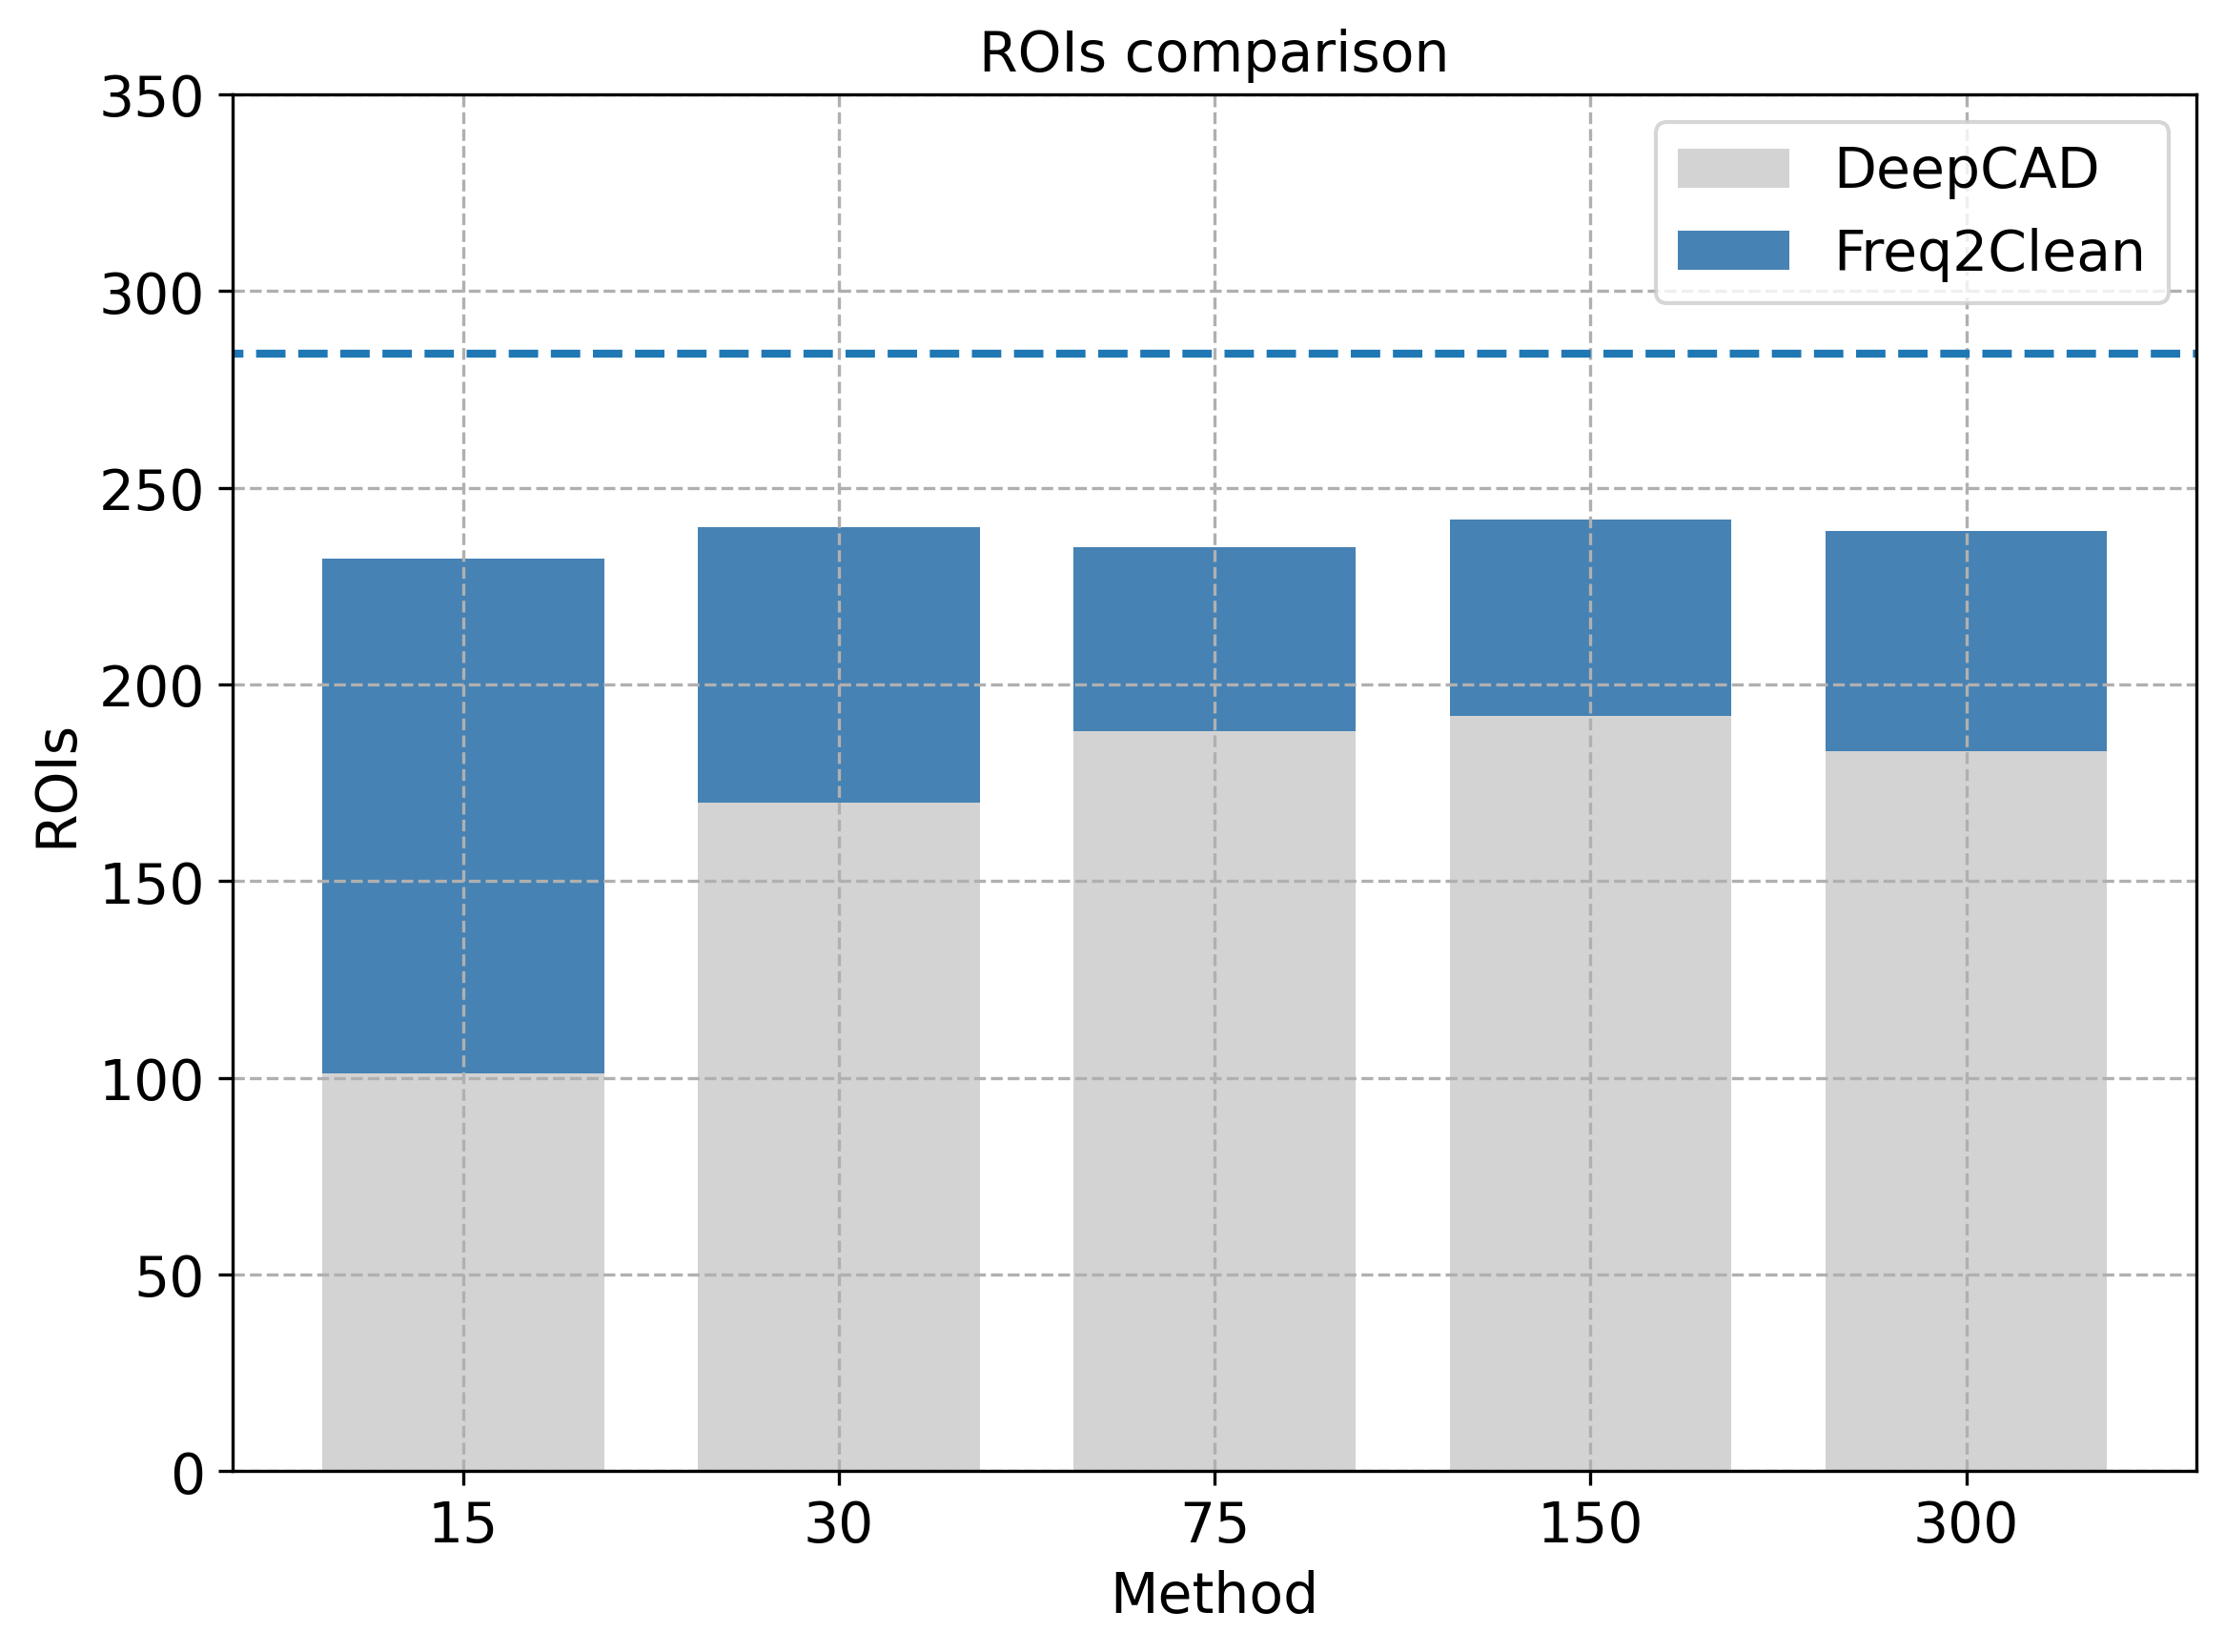

In [ ]:
fft_df = pd.DataFrame(
    [
        ("15", 0.685405, 232.0),
        ("30", 0.729286, 240.0),
        ("75", 0.698760, 235.0),
        ("150", 0.697820, 242.0),
        ("300", 0.711500, 239.0),
    ],
    columns=["Method", "IoU", "ROIs"],
).set_index("Method")

deepcad_df = pd.DataFrame(
    [
        ("15", 0.267517, 101.0),
        ("30", 0.435010, 170.0),
        ("75", 0.453127, 188.0),
        ("150", 0.462333, 192.0),
        ("300", 0.456118, 183.0),
    ],
    columns=["Method", "IoU", "ROIs"],
).set_index("Method")
barchart(deepcad_df, fft_df, "Freq2Clean", "IoU")
barchart(deepcad_df, fft_df, "Freq2Clean", "ROIs", lims=(0, 350), line_y=284)

## Plotting masks
Cellpose returns one `uint` mask for each frame seen

In [2]:
dataset = "synthetic"
variant = 150
segment_net = "cellpose"
meta = DATASETS[dataset]

In [3]:
def norm(data) -> np.ndarray:
    return np.clip(normalize(data, 0.25, 99.5), 0, 1)


def hex2rgb(h):
    h = h.lstrip("#")
    return tuple(int(h[i : i + 2], 16) for i in (0, 2, 4))


def color_confusion(y, gt):
    y = y.astype(bool)
    gt = gt.astype(bool)
    out = np.zeros((*y.shape, 3), dtype=np.uint8)

    tp = y & gt
    fn = ~y & gt
    fp = y & ~gt
    tn = ~y & ~gt

    out[tp] = hex2rgb("#46B62D")
    out[fn] = hex2rgb("#EC3055")
    out[fp] = hex2rgb("#4F96E2")
    out[tn] = hex2rgb("#d2d2d2")
    return out


def mask2l(stats, shape, iou=None, iou_threshold=0, weight_scale=1):
    mask = np.zeros((shape[1], shape[2]), dtype=np.float32)
    for i, stat in enumerate(stats):
        if not iou or iou[i] >= iou_threshold:
            ypix, xpix, lam = stat["ypix"], stat["xpix"], stat["lam"]
            weight = lam / lam.max()
            mask[ypix, xpix] = weight**weight_scale
    return mask

In [4]:
mask_x = np.load(f"{segment_net}_results/{dataset}/x/cpsam_mask.npy")
mask_dcad = np.load(f"{segment_net}_results/{dataset}/deepcad_{variant}/cpsam_mask.npy")
mask_f2c = np.load(f"{segment_net}_results/{dataset}/fft_{variant}/cpsam_mask.npy")
mask_gt = np.load(f"{segment_net}_results/{dataset}/gt/cpsam_mask.npy")
# _iscell_gt = np.load(f"suite2p_results/{dataset}/gt/iscell.npy")
# stat_gt = np.load(f"suite2p_results/{dataset}/gt/stat.npy", allow_pickle=True)[_iscell_gt[:, 0] == 1]
# mask_gt = mask2l(stat_gt, meta.shape, weight_scale=0)

In [40]:
from PIL import Image

mask_gt_corrected_3 = Image.open("manual_corrected_masks/mask_3_corrected.png").convert("L")
mask_gt_corrected_3 = np.where(mask_gt_corrected_3, 1, 0)

In [10]:
x = Recording(meta.x, max_frames=None).np
deepcad = Recording(f"dataset/synthetic/deepcad_{variant}/data.tiff", max_frames=None).np
f2c = Recording(f"dataset/synthetic/fft_{variant}/data.tiff", max_frames=None).np
gt = Recording(meta.gt, max_frames=None).np

In [45]:
mask_x = np.where(mask_x, 1, 0)
mask_dcad = np.where(mask_dcad, 1, 0)
mask_f2c = np.where(mask_f2c, 1, 0)
mask_gt = np.where(mask_gt, 1, 0)
# ious_x = [iou(y, gt) for y, gt in zip(mask_x, mask_gt)]
# ious_dcad = [iou(y, gt) for y, gt in zip(mask_dcad, mask_gt)]
# ious_f2c = [iou(y, gt) for y, gt in zip(mask_f2c, mask_gt)]
# ious_gt = [iou(y, gt) for y, gt in zip(mask_gt, mask_gt)]
cmask_x = color_confusion(mask_x, mask_gt_corrected_3)
cmask_dcad = color_confusion(mask_dcad, mask_gt_corrected_3)
cmask_f2c = color_confusion(mask_f2c, mask_gt_corrected_3)
cmask_gt = color_confusion(mask_gt, mask_gt_corrected_3)

In [46]:
iou(mask_dcad[3], mask_gt_corrected_3), iou(mask_f2c[3], mask_gt_corrected_3), iou(mask_gt[3], mask_gt_corrected_3)

(np.float64(0.46190556873376254),
 np.float64(0.6853026976632282),
 np.float64(0.8701761265235435))

In [ ]:
# pd.Series(ious_x).to_json(f"{segment_net}_results/{dataset}/x/ious.json")
# pd.Series(ious_dcad).to_json(f"{segment_net}_results/{dataset}/deepcad_{variant}/ious.json")
# pd.Series(ious_f2c).to_json(f"{segment_net}_results/{dataset}/fft_{variant}/ious.json")

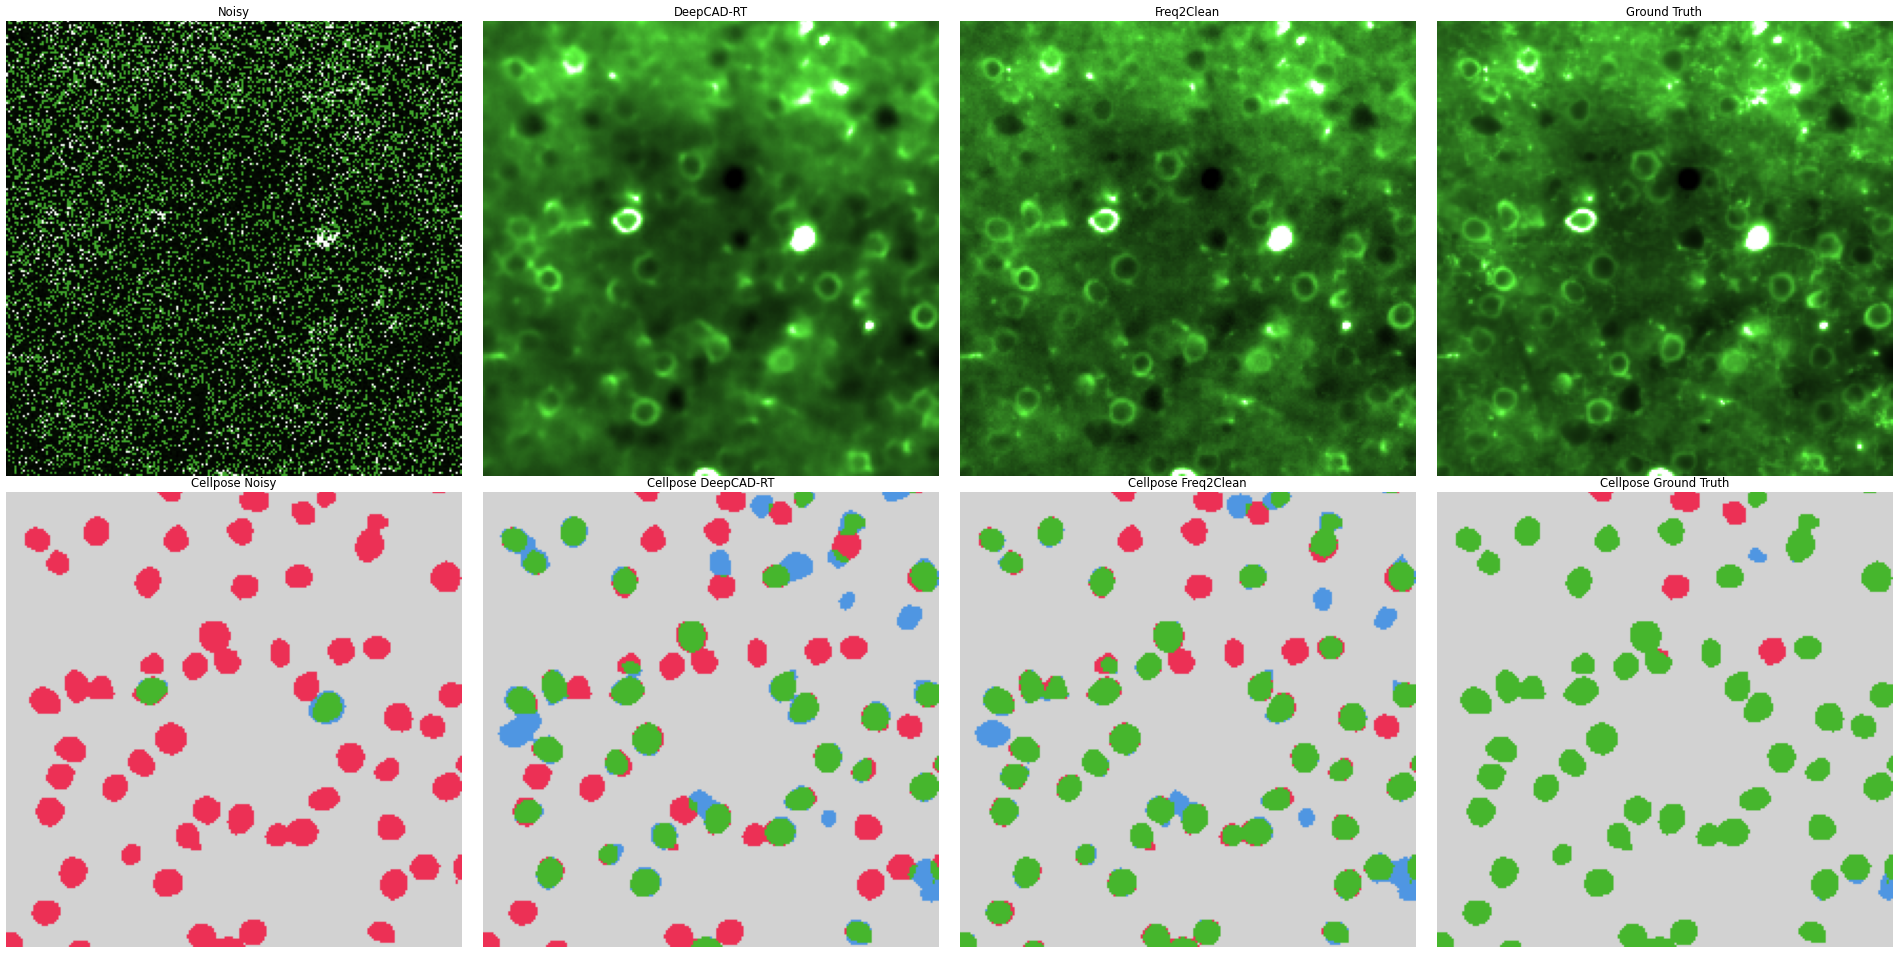

[3]	0.462	0.685	0.87


In [49]:
frames = list(range(0, gt.shape[0], gt.shape[0] // mask_gt.shape[0]))
idxs = sorted(range(mask_gt.shape[0]), key=lambda i: mask_x[i].sum(), reverse=True)
for idx in [3]:
    imshow(
        {
            f"Noisy": norm(x[frames[idx]]),
            f"DeepCAD-RT": norm(deepcad[frames[idx]]),
            f"Freq2Clean": norm(f2c[frames[idx]]),
            f"Ground Truth": norm(gt[frames[idx]]),
            f"Cellpose Noisy": cmask_x[idx],
            f"Cellpose DeepCAD-RT": cmask_dcad[idx],
            f"Cellpose Freq2Clean": cmask_f2c[idx],
            f"Cellpose Ground Truth": cmask_gt[idx],
        },
        size=8,
        cols=4,
        dpi=60,
        zoom=2.25,
        shift=(-128, -128),
        # path=f"cellpose_results/cellpose_{idx}.png"
    )
    cprint(
        f"[{idx}]",
        round(iou(mask_dcad[idx], mask_gt_corrected_3), 3),
        round(iou(mask_f2c[idx], mask_gt_corrected_3), 3),
        round(iou(mask_gt[idx], mask_gt_corrected_3), 3),
        sep="\t",
    )

In [28]:
from PIL import Image

idx=idxs[0]
Image.fromarray((norm(gt[idx])*255).astype(np.uint8)).save(f"gt_{idx}.png")
Image.fromarray(((mask_gt[idx])*255).astype(np.uint8)).save(f"mask_{idx}.png")

In [5]:
imshow({f"Frame {i}": mask_dcad[i] for i in range(mask_dcad.shape[0])})

In [ ]:
def stack_masks(maps: np.ndarray) -> np.ndarray:
    need_to_rename = 1 in maps[0] and 1 in maps[1]
    final_mask = maps[0].copy()
    labels = list(np.unique(final_mask))
    for next_map in maps[1:].copy():
        if need_to_rename:
            next_map[next_map != 0] += np.max(final_mask)
        labels.extend(np.unique(next_map))
        final_mask = np.where(next_map != 0, next_map, final_mask)
    assert len(labels) == len(set(labels)) + maps.shape[0] - 1
    return final_mask


def clean_mask(mask: np.ndarray, min_roi_pixels=15) -> pd.Series:
    assert len(mask.shape) == 2
    counts = {}
    for label in np.unique(mask):
        counts[int(label)] = mask[mask == label].size
    counts = pd.Series(counts)
    for label in counts[counts <= min_roi_pixels].index:
        mask = np.where(mask == label, 0, mask)
    for i, label in enumerate(np.unique(mask)):
        mask = np.where(mask == label, i, mask)
    return mask


def color_mask(mask, min_roi_pixels=50):
    mask = stack_masks(mask)
    mask = clean_mask(mask, min_roi_pixels)
    return mask, plot.mask_rgb(mask)

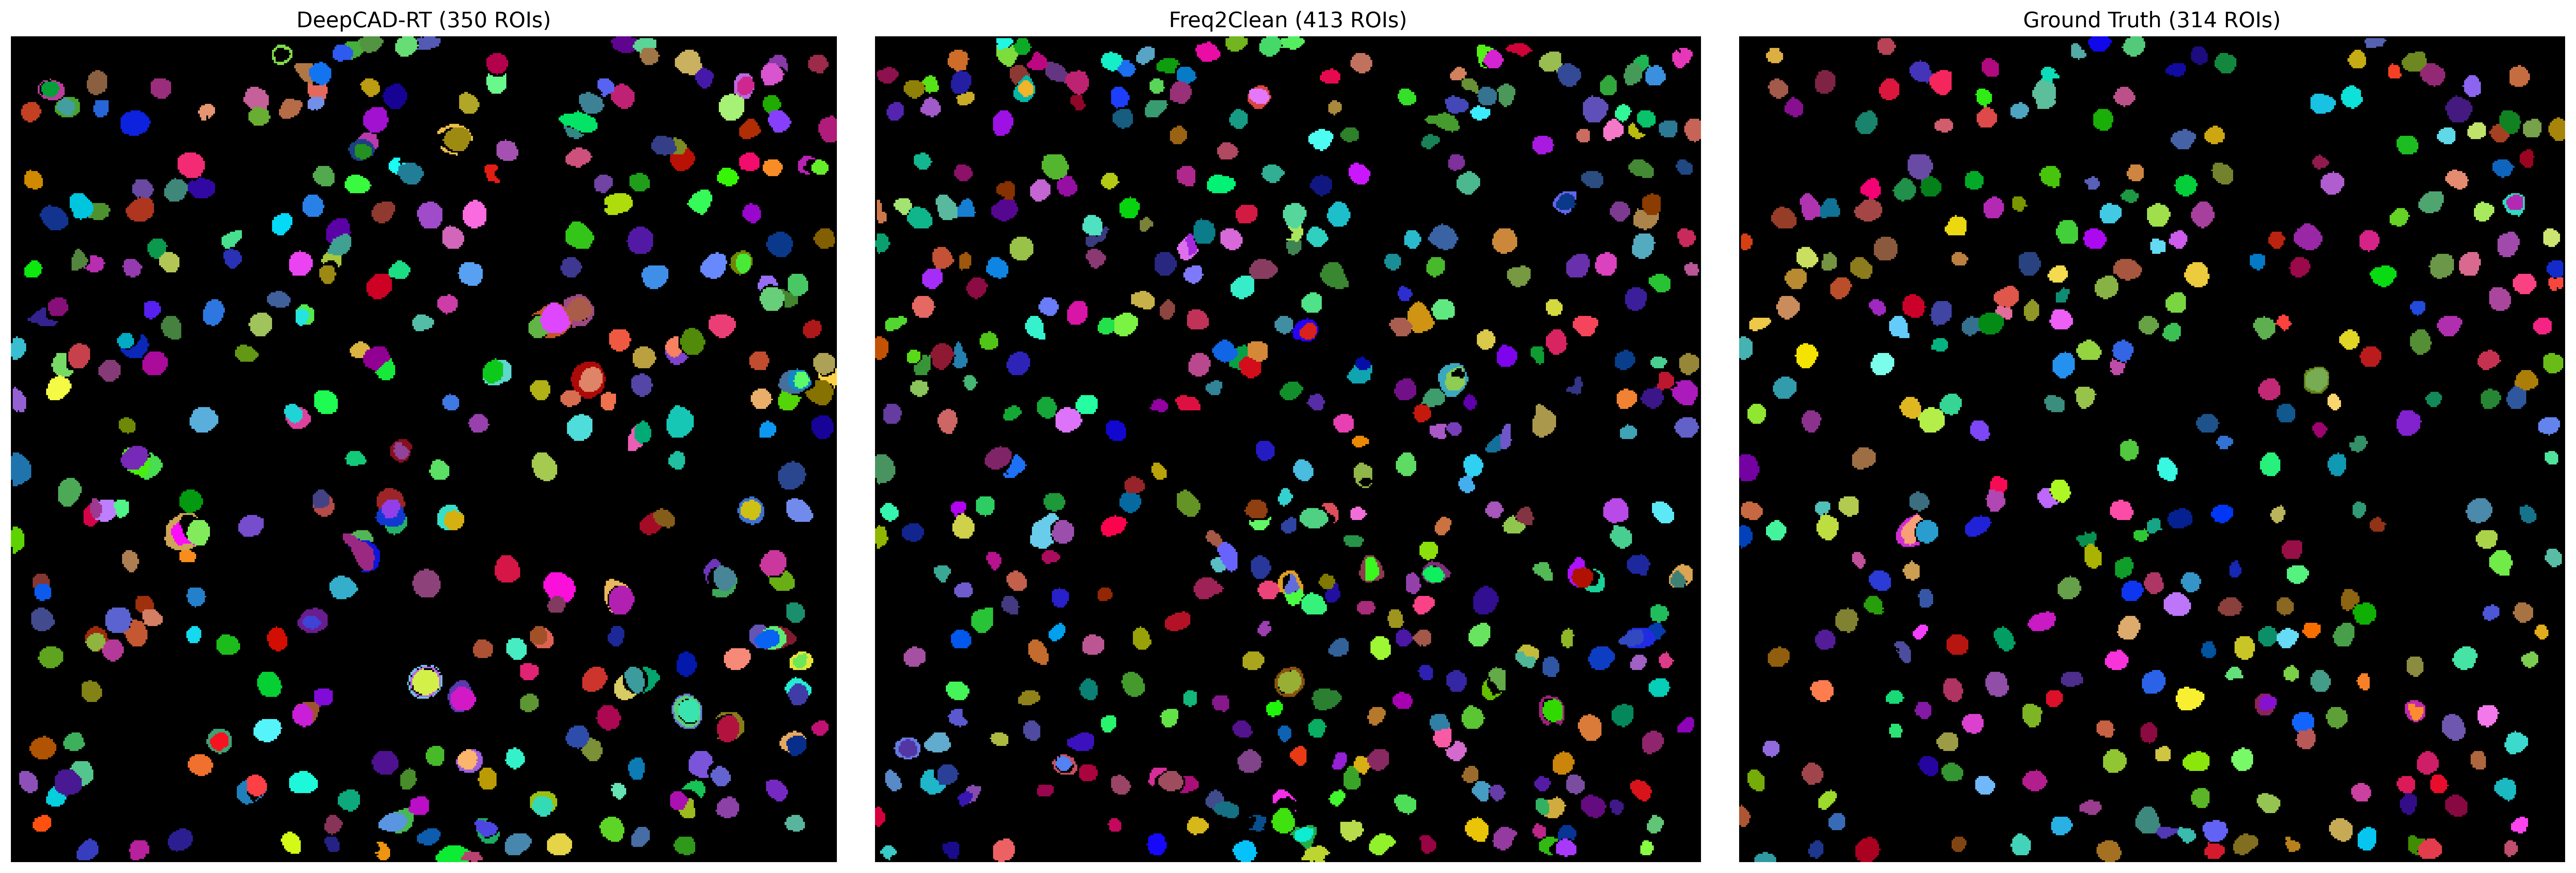

In [7]:
mask_dcad_cleaned, mask_dcad_color = color_mask(mask_dcad)
mask_f2c_cleaned, mask_f2c_color = color_mask(mask_f2c)
mask_gt_cleaned, mask_gt_color = color_mask(mask_gt)
imshow(
    {
        f"DeepCAD-RT ({np.max(mask_dcad_cleaned)} ROIs)": mask_dcad_color,
        f"Freq2Clean ({np.max(mask_f2c_cleaned)} ROIs)": mask_f2c_color,
        f"Ground Truth ({np.max(mask_gt_cleaned)} ROIs)": mask_gt_color,
    },
    size=8,
)

In [151]:
np.save(f"{segment_net}_results/{dataset}/deepcad_{variant}/cpsam_mask_cleaned.npy", mask_dcad_cleaned)
np.save(f"{segment_net}_results/{dataset}/fft_{variant}/cpsam_mask_cleaned.npy", mask_f2c_cleaned)
np.save(f"{segment_net}_results/{dataset}/gt/cpsam_mask_cleaned.npy", mask_gt_cleaned)